# Default packages and General helper functions

In [52]:
# Data types
from typing import List, Optional, Union
from enum import Enum
from numpy.typing import NDArray

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.patches as patches
import pandas as pd

# Data handling
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm

# UNet
import torch
from torch import nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# RL Environment
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box, Discrete, Dict, Tuple
from gymnasium import spaces

# RL training
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy

# Saving and loading
import pickle

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"{device=}")


device='cuda'


In [2]:
# Observation space
class Tile(Enum):
  OCEAN = 0
  SUBMARINE = 1
  ISLAND = 2
  TRAVELLED = 3

# Action space
class Action(Enum):
  UP = 0
  DOWN = 1
  LEFT = 2
  RIGHT = 3
  NOTHING = 4

_vectorize_action = {
    # Going from row 1 to 0 is UP
    Action.UP.value:      np.array([ -1 ,  0 ]),
    # Going from row 0 to 1 is DOWN
    Action.DOWN.value:    np.array([  1 ,  0 ]),
    # Going from column 1 to 0 is LEFT
    Action.LEFT.value:    np.array([  0 , -1 ]),
    # Going from column 0 to 1 is RIGHT
    Action.RIGHT.value:   np.array([  0 ,  1 ]),
    Action.NOTHING.value: np.array([  0 ,  0 ]),
}

board_numpy = np.array(
    [
        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 0, 2, 0, 0,  0, 2, 0, 0, 0,  0, 0, 2, 2, 0],
        [0, 0, 2, 0, 0,  0, 0, 0, 2, 0,  0, 0, 2, 0, 0],
        [0, 0, 0, 0, 0,  0, 0, 0, 2, 0,  0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],

        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 2, 0, 2, 0,  0, 2, 0, 2, 0,  0, 0, 0, 0, 0],
        [0, 2, 0, 2, 0,  0, 2, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 0, 0, 2, 0,  0, 0, 2, 0, 0,  0, 2, 2, 2, 0],
        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],

        [0, 0, 0, 2, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 0, 2, 0, 0,  0, 0, 2, 0, 0,  0, 2, 0, 0, 0],
        [2, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 2, 0, 0],
        [0, 0, 2, 0, 0,  0, 2, 0, 2, 0,  0, 0, 0, 2, 0],
        [0, 0, 0, 2, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
    ]
)

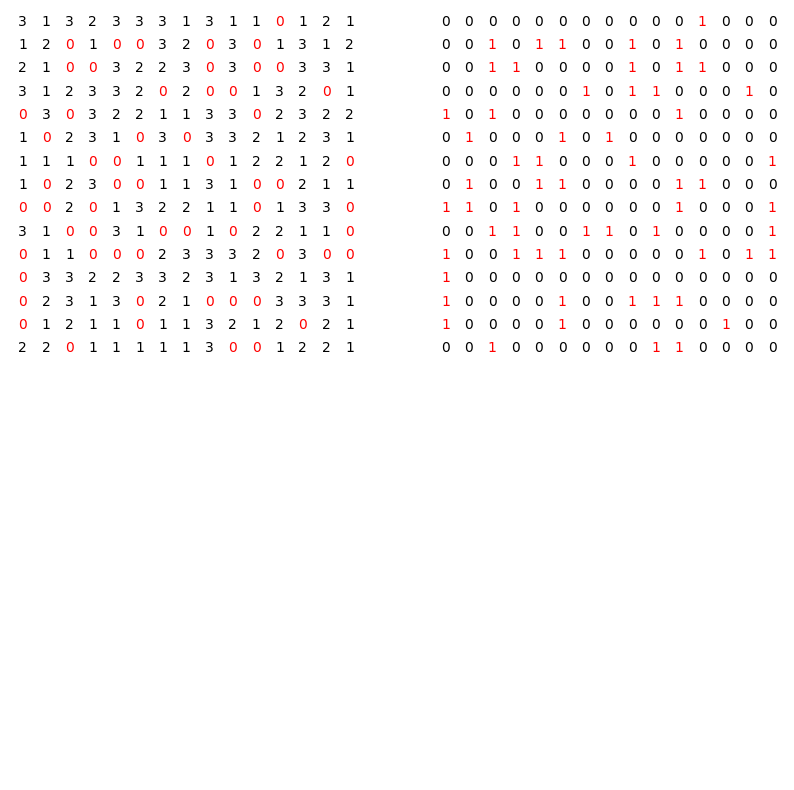

In [3]:
# Generate a 15x15 grid with numbers ranging from 0 to 3
matrix = np.random.randint(0, 4, (15, 15))
matrix_2 = np.where(matrix == 0, 1, 0)
zeroes = np.zeros((15, 15))

# Show each number on each grid cell
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
# White cmap to show the numbers clearly, with 0 as red and 1 as white
ax[0, 0].imshow(zeroes, vmin=0, vmax=1, cmap='Greys')
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if matrix[i, j] == 0:
            color = "red"
        else:
            color = "black"
        ax[0, 0].text(j, i, str(matrix[i, j]), ha='center', va='center', color=color)
    

ax[0, 1].imshow(zeroes, vmin=0, vmax=3, cmap='Greys')
for i in range(matrix_2.shape[0]):
    for j in range(matrix_2.shape[1]):
        if matrix_2[i, j] == 1:
            color = "red"
        else:
            color = "black"
        ax[0, 1].text(j, i, str(matrix_2[i, j]), ha='center', va='center', color=color)


for a in ax.flatten():
    a.axis('off')

plt.show()

# All code for UNet

<!-- Template
<details>
<summary>&#10004; [Text] </summary>
[Explanation]
</details>
 -->

**UNet Clarity**

<details>
<summary>&#10004; Standardize inputs for all UNet functions </summary>
Provide data type hints to UNet functions <br>
Add check functions that make sure proper dimensions are put in
</details>
<details>
<summary> &#10004; Implement resurfacing </summary>
Idea: Project resurfacing onto separate input <br>
Explanation: Each time the sub resurfaces, it gets recorded which section it resurfaces. This section is projected in a separate input.  The sequence recorded is started from empty again. Each path begins with no section or with a section
</details>
<details>
<summary>&#10005; Adept the new UNet code from BEP phase 3 to BEP phase 4 </summary>
Adjust the standardize masks with masks to pans <br>
Adjust the train_model
</details>

## UNet functions

In [26]:
# Standardize UNet-helper functions
# Accepts only 2D — (15, 15)
# Accepts only numpy

grid_size = 15

function_submarine_value = 2
function_travelled_value = 1

# Data needed for UNet
board_UNet = np.where(board_numpy == 2, 0, 1)

def add_islands(ax):
    for x in range(grid_size):
        for y in range(grid_size):
            if board_numpy[x, y] == 2:
                circle = Circle((y, x), 0.5, fill=True, color="green", alpha=1)
                ax.add_patch(circle)

def sections_to_masks(sections : List[Optional[int]]) -> NDArray[np.int_]:
    masks = np.zeros((len(sections), grid_size, grid_size), dtype=np.int_)

    for index, section in enumerate(sections):
        if section == None or section == -1:
            continue;
        for x_area in range(5):
            for y_area in range(5):
                x, y = x_area + (section // 3) * 5, y_area + (section % 3) * 5
                masks[index, x, y] = 1
    return masks

def actions_to_paths(actions : List[Union[str, List[int]]]) -> List[List[np.ndarray]]:
    if type(actions[0]) == list:
        sequences = [[_vectorize_action[direction] for direction in action] for action in actions]
    if type(actions[0]) == str:
        sequences = [[_vectorize_action[int(number_string)] for number_string in string.strip().split(" ")] for string in actions]
    sequences = [[np.array([0, 0])] + nested_list for nested_list in sequences]

    for sequence in sequences:
        for i, vector in enumerate(sequence[1:]):
            sequence[i + 1] = sequence[i] + vector

            if np.any(sequence[i + 1] < 0):
                sequence[:i + 2] = sequence[:i + 2] - vector
    return sequences

def paths_to_masks(paths : List[List[np.ndarray]]) -> NDArray[np.int_]:
    paths_masked = np.zeros((len(paths), grid_size, grid_size))
    for index, path in enumerate(paths):
        for i, pos in enumerate(path):
            x, y = pos[0], pos[1]
            if i == len(path) - 1:
                paths_masked[index, x, y] = function_submarine_value
            else:
                paths_masked[index, x, y] = function_travelled_value

    return paths_masked

def standardize_masks(masks : NDArray[np.int_]) -> NDArray[np.int_]:
    filters, _ = masks_to_pans(masks)

    # Find how many rows and columns to pad for each filter
    pad_rows = [15 - filter.shape[0] for filter in filters]
    pad_cols = [15 - filter.shape[1] for filter in filters]
    # As filters are homogeneous, we need to pad for each filter separately without numpy :(
    standardized_masks = [np.pad(
        filter,
        pad_width=((0, pad_row), (0, pad_col)),
        mode='constant',
        constant_values=0
    ) for filter, pad_row, pad_col in zip(filters, pad_rows, pad_cols)]
    # Make it a numpy array as it is standardized to (N, 15, 15)
    return np.array(standardized_masks)

def check_2D(array : NDArray[np.int_]) -> bool:
    if len(array.shape) == 2:
        return True
    raise ValueError(f"Only 2D arrays are accepted {array.shape=}")

def mask_to_pan(mask : NDArray[np.int_]) -> tuple[NDArray[np.int_], int]:
    # Only accept 2D arrays
    check_2D(mask)
    grid_size = mask.shape[0]
    pan = mask.copy()
    # Get rid of empty rows and columns
    pan = pan[np.abs(pan.sum(axis=1)) != 0]
    pan = pan.T[np.abs(pan.sum(axis=0)) != 0].T
    # Get the position of submarine in pan
    indices = np.where(pan == function_submarine_value)
    (x, y) = indices
    # Return pan and project submarine pan position to original grid
    flattened_grid_position = x * grid_size + y
    return (pan, flattened_grid_position)

def masks_to_pans(masks : NDArray[np.int_]) -> tuple[List[NDArray[np.int_]], List[int]]:
    if len(masks.shape) != 3:
        raise ValueError(f"Expected masks shape is 3D, got {masks.shape=}")
    if type(masks) != np.ndarray:
        raise ValueError(f"Expected masks type is np.ndarray, got {type(masks)=}")

    # Find the empty rows and columns
    X = masks.sum(axis=1) != 0
    Y = masks.sum(axis=2) != 0
    # Get rid of the empty rows and columns
    filters = [mask[y_mask].T[x_mask].T for mask, x_mask, y_mask in zip(masks, X, Y)]
    # Find flat sub positions in the original grid
    indices_x, indices_y = np.where(masks == function_submarine_value)[1:]
    sub_positions = indices_x * 15 + indices_y
    return filters, sub_positions

def deterministic_sub_finding(mask : NDArray[np.int_], board : NDArray[np.int_]) -> NDArray[np.float64]:
    # Only accept 2D arrays
    check_2D(mask)
    check_2D(board)

    # Get the pan for panning
    pan, sub_pos = mask_to_pan(mask)

    # Get the shape of the pan and the board to calculate the output shape of convolution
    x_shape, y_shape = pan.shape
    X_shape, Y_shape = board.shape
    x_out, y_out = X_shape - x_shape + 1, Y_shape - y_shape + 1

    # Change to torch tensors and add batch and channel dimensions required for convolution
    board_torch = torch.tensor(board).view(1, 1, X_shape, Y_shape).float()
    pan_torch = torch.tensor(pan).view(1, 1, x_shape, y_shape).float()

    # Perform the Convolution
    output = F.conv2d(board_torch, pan_torch, stride=1, padding=0)

    # Check values of each position, as islands are worth 0 and ocean is worth 1, the maximum value of convolution is the sum of pan
    output = torch.where(output == pan_torch.sum(), 1, 0)

    # Normalize the output to get a probability distribution
    output = output / output.sum()

    # Offset the position of possible submarine locations to the original grid
    # Convolution output is always smaller than the original grid
    flattened_output = output.flatten().cpu().detach().numpy()
    flat_matrix = np.zeros((X_shape * Y_shape))
    for position in range(x_out * y_out):
        value = flattened_output[position]
        if value > 0:
            x_smaller, y_smaller = position // y_out, position % y_out
            adjusted_position = x_smaller * grid_size + y_smaller
            flat_matrix[adjusted_position + sub_pos] = value

    # Reshape the flat matrix back to the original grid shape
    matrix = flat_matrix.reshape(X_shape, Y_shape)
    return matrix

In [58]:
def compare_UNet_to_Deterministic(test_data_loader, model):
    scores = np.zeros((len(test_data_loader), 3))
    for masked_path, final_position, board, path, index in tqdm(test_data_loader):
        # Whole board has sum probability of 1
        deterministic_output = deterministic_sub_finding(masked_path.squeeze().cpu().detach().numpy(), board.squeeze().cpu().detach().numpy())
        # Each tile on this board can have probability of [0, 1]. The sum of board would be higher than 1
        UNet_output = model(masked_path, board)
        # Normalize whole UNet output to sum to 1
        UNet_output = torch.softmax(UNet_output, dim=1)

        # Detach from cuda
        deterministic_output = deterministic_output
        UNet_output = UNet_output.cpu().detach().numpy().squeeze().reshape(15, 15)
        final_position = final_position.cpu().detach().numpy().squeeze()

        # Transform final position to x and y
        x_final = final_position % 15
        y_final = final_position // 15

        # Calculate the distance from final_position * probability for each tile and sum it up
        distance_matrix_x = np.array(list(range(15)) * 15).reshape(15, 15)
        distance_matrix_y = distance_matrix_x.T

        # Calculate the distance from final_position for each tile
        # distance_from_final = np.abs(distance_matrix_x - x_final) + np.abs(distance_matrix_y - y_final)
        distance_from_final = np.maximum(np.abs(distance_matrix_x - x_final), np.abs(distance_matrix_y - y_final))
        
        # Calculate the expected probability
        UNet_estimation = (distance_from_final * UNet_output).sum()
        Deterministic_estimation = (distance_from_final * deterministic_output).sum()

        scores[index, 0] = UNet_estimation
        scores[index, 1] = Deterministic_estimation
        scores[index, 2] = len(path)

    scores_df_initial = pd.DataFrame(scores, columns=["UNet", "Deterministic", "Length"])
    scores_df_initial["Length"] = scores_df_initial["Length"].astype(int)

    scores_df_UNet = pd.DataFrame(scores_df_initial["UNet"], columns=["score"])
    scores_df_UNet["score"] = scores_df_initial["UNet"]
    scores_df_UNet["Length"] = scores_df_initial["Length"]
    scores_df_UNet["Method"] = "UNet"
    scores_df_Deterministic = pd.DataFrame(scores_df_initial["Deterministic"], columns=["score"])
    scores_df_Deterministic["score"] = scores_df_initial["Deterministic"]
    scores_df_Deterministic["Length"] = scores_df_initial["Length"]
    scores_df_Deterministic["Method"] = "Deterministic"

    scores_df = pd.concat([scores_df_UNet, scores_df_Deterministic], ignore_index=True).reset_index(drop=True)

    std_df = pd.pivot_table(
        scores_df,
        values="score",
        index="Method",
        columns="Length",
        aggfunc=["mean", "std"]
    ).round(2)

    fig, ax = plt.subplots(figsize=(20, 6))

    for method, stats in std_df.iterrows():
        mean = stats[:len(stats)//2].values
        std = stats[len(stats)//2:].values

        if len(mean) > len(std):
            mean = mean[:len(std)]
        else:
            std = std[:len(mean)]

        threshold = mean + std
        for index, value in enumerate(threshold):
            if value < 1:
                print(f"Method {method} has mean + std < 1 at path length {index + 5} with {value=}")
        
        ax.plot(range(5, len(mean) + 5), mean, label=f"Method {method}", color="#1b9e77" if method == "UNet" else "#d95f02")
        ax.fill_between(range(5, len(mean) + 5), np.maximum(mean - std, 0), mean+std, alpha=0.2, color="#1b9e77" if method == "UNet" else "#d95f02")
    ax.set_xticks(range(5, 101, 5))
    ax.set_yticks(range(0, 12, 1))

    ax.set_xlabel("Path Length")
    ax.set_ylabel("Penalty score")
    ax.legend()
    plt.show()

In [5]:
def check_4D(array : NDArray[np.int_]) -> bool:
    if len(array.shape) == 4:
        return True
    raise ValueError(f"Only 4D arrays are accepted {array.shape=}")

class SequenceMapped(Dataset):
    def __init__(self, mapped_paths, final_positions, board):
        self.mapped_paths = torch.tensor(mapped_paths).unsqueeze(1).float()
        self.final_positions = torch.tensor(np.array(final_positions)).unsqueeze(1).long()
        self.board = torch.tensor(board).float().unsqueeze(0).repeat(self.mapped_paths.shape[0], 1, 1).unsqueeze(1)

        check_4D(self.mapped_paths)
        check_4D(self.board)
        check_2D(self.final_positions)

    def __len__(self):
        return self.final_positions.size()[0]

    def __getitem__(self, index):   
        return self.mapped_paths[index], self.final_positions[index], self.board[index]
    
class SequenceMappedTest(SequenceMapped):
    def __init__(self, mapped_paths, final_positions, board, paths):
        # List of strings to list of list of numbers
        super().__init__(mapped_paths, final_positions, board)
        self.paths = paths

    def __getitem__(self, index):
        return self.mapped_paths[index], self.final_positions[index], self.board[index], self.paths[index], index

In [6]:
# UNet architecture inspired by https://arxiv.org/abs/1505.04597

class UNet(nn.Module):
    def __init__(self, num_channels, input_channel = 2, grid_size=15, num_directions= len(Action), bias=True):
        super().__init__()

        self.grid_size = grid_size

        self.UPSAMPLE = nn.Upsample(scale_factor=2)
        self.DOWNSAMPLE = nn.MaxPool2d(2, 2)
        self.INPUT = nn.Sequential(
            nn.Conv2d(input_channel, num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels,  num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels,  num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
        )
        self.DOWN1 = nn.Sequential(
            nn.Conv2d(num_channels,     num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2, num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2, num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
        )
        self.BOTTOM = nn.Sequential(
            nn.Conv2d(num_channels * 2, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
            nn.ReLU(),
            nn.Conv2d(num_channels * 4, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
            nn.ReLU(),
            nn.Conv2d(num_channels * 4, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
        )
        self.UP1 = nn.Sequential(
            nn.Conv2d(num_channels * 2 + num_channels * 4 , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2                    , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2                    , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
        )
        self.OUTPUT = nn.Sequential(
            nn.Conv2d(num_channels * 1 + num_channels * 2 , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , 1               , kernel_size=3, padding=1, stride=1, bias=bias),
            nn.BatchNorm2d(1),
            nn.ReLU()
        )
        self.softmax = nn.LogSoftmax(dim=1)
        self.flatten = nn.Flatten()

    def forward(self, mapping : torch.Tensor, board : torch.Tensor) -> torch.Tensor:
        # Pad such that it is 16x16 for the downsampling and upsampling to work properly
        board_padded = F.pad(board, (0, 1, 0, 1))
        mapping_padded = F.pad(mapping, (0, 1, 0, 1))

        # Stack X_padded and board_padded
        stacked = torch.hstack((board_padded, mapping_padded)).float()
        Layer1Encoder = self.INPUT(stacked)
        Layer1EncoderDownsample = self.DOWNSAMPLE(Layer1Encoder)
        Layer2Encoder = self.DOWN1(Layer1EncoderDownsample)
        Layer2EncoderDownsample = self.DOWNSAMPLE(Layer2Encoder)
        BOTTLENECK = self.BOTTOM(Layer2EncoderDownsample)

        BOTTLENECKUpsample = self.UPSAMPLE(BOTTLENECK)
        stacked = torch.hstack((Layer2Encoder, BOTTLENECKUpsample))
        Layer2Decoder = self.UP1(stacked)

        Layer2DecoderUpsample = self.UPSAMPLE(Layer2Decoder)
        stacked = torch.hstack((Layer1Encoder, Layer2DecoderUpsample))
        i2o_padded = self.OUTPUT(stacked)

        # Remove the padding
        i2o = i2o_padded[:, :, :self.grid_size, :self.grid_size]
        # Mask using the board to exploit information about islands
        i2o = i2o * board
        # CrossEntropyLoss applies softmax internally, make sure input is 1D
        i2o = self.flatten(i2o)

        return i2o

In [7]:
def train_model(
    train_data,
    test_data,
    visualize_data,
    model,
    loss_fn,
    epochs=10,
    lr=0.01,
    print_every=1,
    visualize_images=100,
    batch_size=32,
    visualize_every = 10
):
    loss_dict = {"train": [], "test": []}

    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=device))
    visualize_data_loader = DataLoader(visualize_data, batch_size=1, shuffle=True, generator=torch.Generator(device=device))
    test_data_loader = DataLoader(test_data, batch_size=256, shuffle=True, generator=torch.Generator(device=device))
    optimizer = Adam(model.parameters(), lr=lr)

    # Print header.
    print(f"Epoch    Train RMSRE      Test RMSRE")

    for epoch in range(epochs):
        model.train()
        epoch_loss_sum = 0

        for mapped_path, final_position, board in tqdm(train_data_loader):

            # Reset optimizer gradients.
            optimizer.zero_grad()
            output = model(mapped_path, board)

            # Compute the loss
            loss = loss_fn(output, final_position.squeeze(1))
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        with torch.no_grad():
            model.eval()

            vis_count = 0
            if visualize_every > 0 and (epoch + 1) % visualize_every == 0:
                for masked_path, final_position, board, path, index in visualize_data_loader:
                    vis_count += 1
                    if vis_count > visualize_images:
                        break;
                    
                    output = model(masked_path, board)

                    fig, ax = plt.subplots(1, 2, figsize = (8, 8))
                    ax[0].imshow(output.cpu().detach().numpy().squeeze().reshape(15, 15))
                    deterministic_output = deterministic_sub_finding(masked_path.cpu().detach().numpy().squeeze(), board.cpu().detach().numpy().squeeze())
                    ax[1].imshow(deterministic_output.squeeze())

                    add_islands(ax[0])
                    add_islands(ax[1])

                    length_path = len(path)
                    for index, pos in enumerate(path):
                        pos = pos.cpu().detach().flatten()
                        y, x = pos[0], pos[1]
                        alpha = ((index+1) / length_path) ** 2
                        alpha = 1
                        circle = Circle((x, y), 0.2, fill=True, color="red", alpha=alpha)
                        ax[0].add_patch(circle)
                        circle = Circle((x, y), 0.2, fill=True, color="red", alpha=alpha)
                        ax[1].add_patch(circle)

                    index = np.argmax(output.cpu().detach().numpy().squeeze().reshape(15, 15))
                    x = index % 15
                    y = index // 15
                    circle = Circle((x, y), 0.2, fill=True, color="black", alpha=1)
                    ax[0].add_patch(circle)
                    circle = Circle((x, y), 0.2, fill=True, color="black", alpha=1)
                    ax[1].add_patch(circle)

                    final_position = final_position.cpu().detach().flatten()
                    x = final_position % 15
                    y = final_position // 15
                    circle = Circle((x, y), 0.2, fill=True, color="blue", alpha=1)
                    ax[0].add_patch(circle)
                    circle = Circle((x, y), 0.2, fill=True, color="blue", alpha=1)
                    ax[1].add_patch(circle)

                    for a in ax.flat:
                        a.axis('off')

                    ax[0].set_title("UNet Heatmap Output")
                    ax[1].set_title("Deterministic Heatmap Output")

                    plt.show()

            test_loss = 0
            for mapped_path, final_position, board in test_data_loader:
                test_pred = model(mapped_path, board)
                test_loss += loss_fn(test_pred, final_position.squeeze(1)).item()

            loss_dict["test"].append(test_loss / len(test_data_loader))

            if (epoch + 1) % print_every == 0:
                print(
                    f"{epoch+1: <7}  {loss_dict['train'][-1]: <12.6e}  {loss_dict['test'][-1]: .6e}"
                )

    model.eval()
    return model, loss_dict

def plot_losses(train, test):
    plt.semilogy(train, label="train", marker=".", lw=2)
    plt.semilogy(test, label="test", marker=".", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("RMSRE")
    plt.legend()
    plt.show()

In [8]:
def make_datasets(paths, standardized_sequences, board):
    random_seed = 42

    sequences = []
    subdivided_paths = []

    for path, sequence in zip(paths, standardized_sequences):
        for i in range(5, min(len(path), 101)):
            sequences.append(sequence[:i])
            subdivided_paths.append(path[:i])
    print(f"{len(sequences)=}, {len(subdivided_paths)=}")

    masks_current = paths_to_masks(sequences)
    print("Masks created")
    paths_mapped_standardized = standardize_masks(masks_current)
    print("Masks standardized")
    final_positions = [path[-1][0] * 15 + path[-1][1] for path in subdivided_paths]
    print("Final positions calculated")

    percentage = 0.2
    train_inputs, test_inputs, train_labels, test_labels = train_test_split(
        paths_mapped_standardized, final_positions, test_size=percentage, random_state=random_seed, shuffle=True
    )
    print("Train test split done")
    _, _, train_paths, test_paths = train_test_split(
        paths_mapped_standardized, subdivided_paths, test_size=percentage, random_state=random_seed, shuffle=True
    )
    print("Paths split done")

    train_data_current = SequenceMapped(train_inputs, train_labels, board)
    test_data_current = SequenceMapped(test_inputs, test_labels, board)
    visualize_data_current = SequenceMappedTest(test_inputs, test_labels, board, test_paths)
    print("Datasets created")

    print("Allocated memory:", torch.cuda.memory_allocated())

    return train_data_current, test_data_current, visualize_data_current

## Data and Training

In [47]:
# Test the code

with open("intermediate_sequences.pkl", 'rb') as file:
  intermediate_sequences = pickle.load(file)
with open("intermediate_paths.pkl", 'rb') as file:
  intermediate_paths_duplicates = pickle.load(file)

indexes = [[pos[0] * 15 + pos[1] for pos in path] for path in intermediate_paths_duplicates]
indexes = [np.array(path) for path in indexes]
for i, path in enumerate(indexes):
  if len(np.unique(path)) < len(path):
    unique_values, indices = np.unique(path, return_index=True)
    ordered_unique = unique_values[np.argsort(indices)]
    indexes[i] = ordered_unique

intermediate_paths = [[np.array([index // 15, index % 15]) for index in list(path)] for path in indexes]

paths_sequences_standardized = actions_to_paths(intermediate_sequences)
for index, (sequence, path) in enumerate(zip(paths_sequences_standardized, intermediate_paths)):
    if len(sequence) != len(path):
        paths_sequences_standardized[index] = path[:len(path)]

In [125]:
train_data_current_2, test_data_current_2, visualize_data_current_2 = make_datasets(intermediate_paths[:1000], paths_sequences_standardized[:1000], board_UNet)


len(sequences)=54681, len(subdivided_paths)=54681
Masks created
Masks standardized
Final positions calculated
Train test split done
Paths split done
Datasets created
Allocated memory: 2054937600


Epoch    Train RMSRE      Test RMSRE


100%|██████████| 175/175 [00:13<00:00, 12.64it/s]


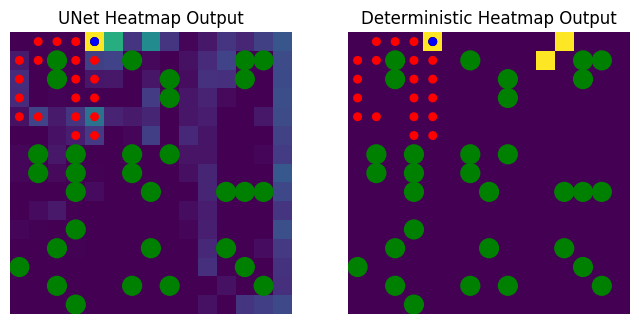

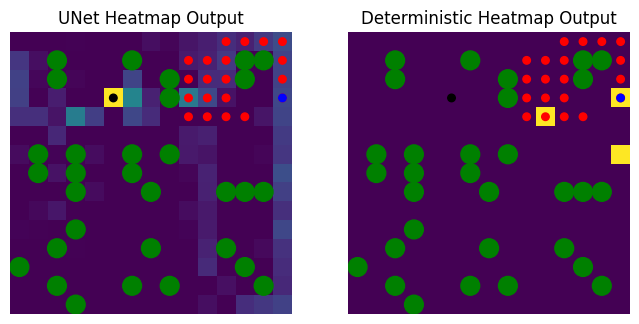

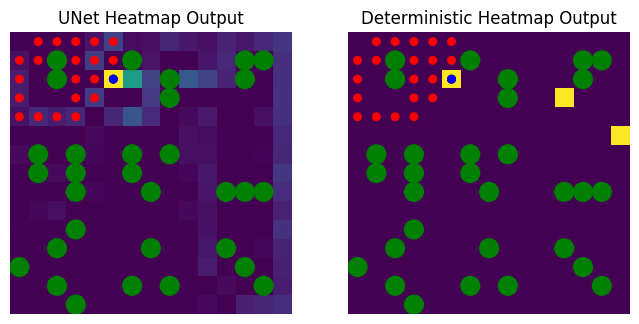

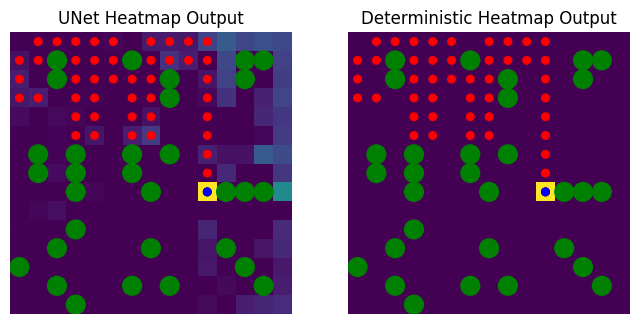

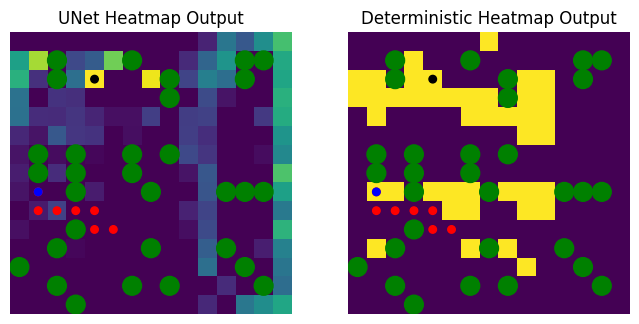

1        3.172977e+00   2.645981e+00


100%|██████████| 175/175 [00:13<00:00, 13.01it/s]


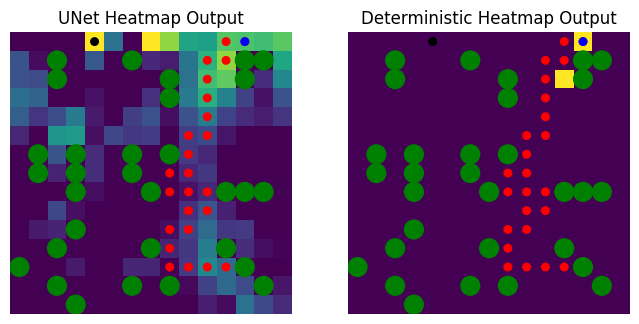

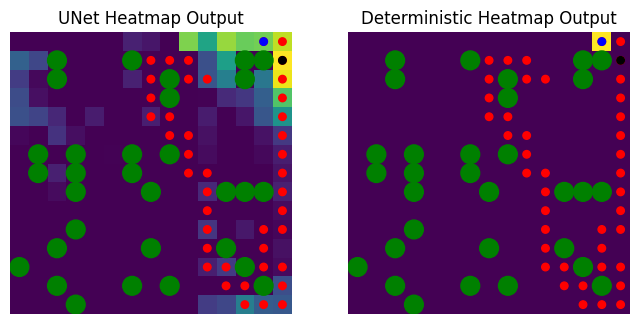

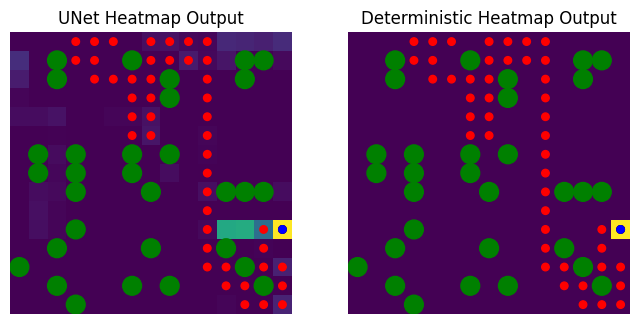

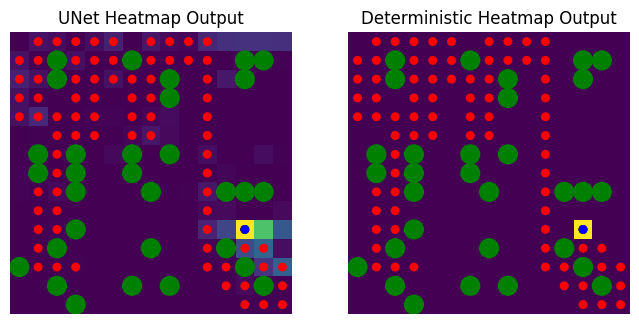

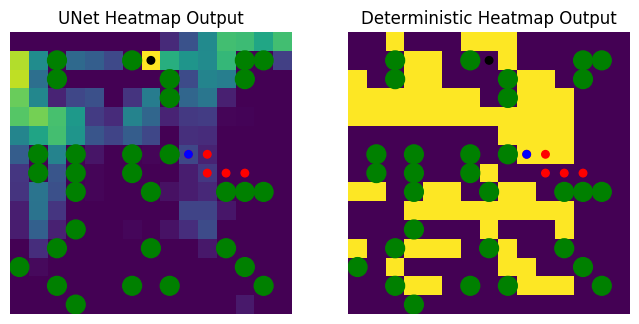

2        2.238516e+00   1.999990e+00


100%|██████████| 175/175 [00:13<00:00, 13.01it/s]


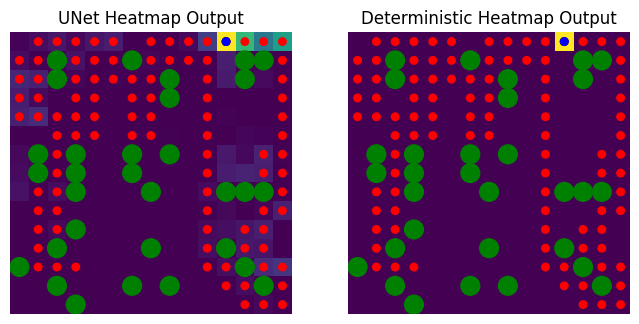

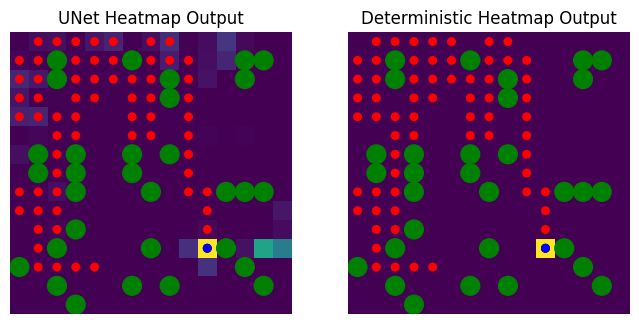

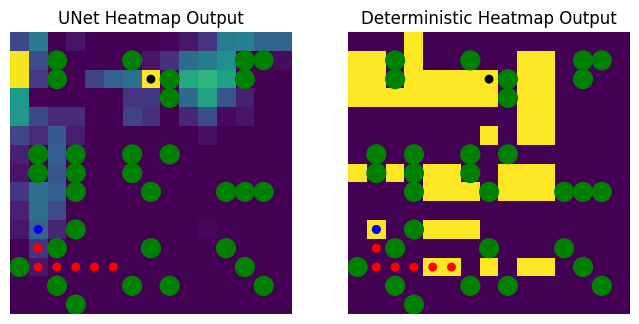

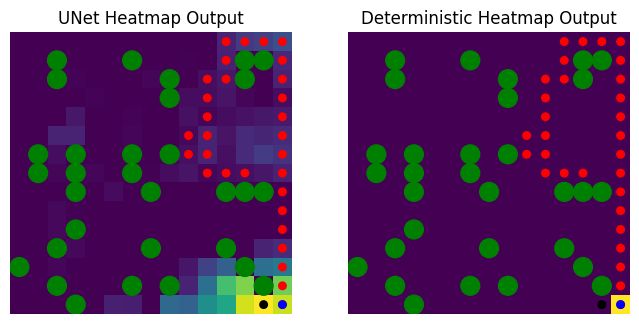

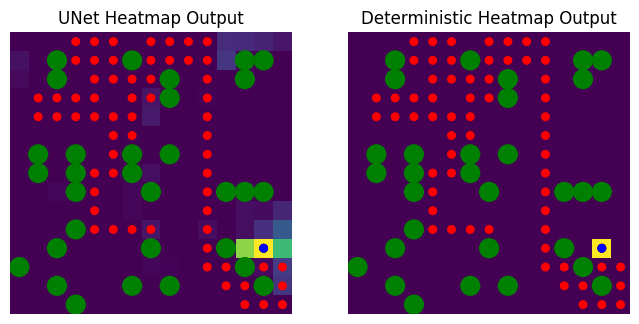

3        1.739356e+00   1.693064e+00


 77%|███████▋  | 135/175 [00:10<00:03, 12.45it/s]


KeyboardInterrupt: 

In [126]:
initial_UNet_model, loss_dict = train_model(
    train_data = train_data_current_2,
    test_data = test_data_current_2,
    visualize_data = visualize_data_current_2,
    model = UNet(32, bias=True),
    loss_fn = nn.CrossEntropyLoss(),
    epochs=10,
    lr=1e-4,
    print_every=1,
    visualize_images=5,
    batch_size=256
)

## Loading in model

In [9]:
# Load in UNet trained on Agent 2 and 4
model_2_4_current = UNet(32, bias=True)
model_2_4_current.load_state_dict(torch.load('model_2_4_current_weights.pth'))
model_2_4_current.eval()
print("Model loaded")

Model loaded


# All code for RL Agent 2 and 4


<!-- Template
<details>
<summary>&#10005; [Text] </summary>
[Explanation]
</details>
 -->


**RL Clarity**

<details>
<summary> &#10004; Implement the coordinates send from torpedo </summary>
&#10004; Add another observation key in the observation Dict for both agents <br>
&#10004; Add the reset of torpedo coordinates <br>
&#10004; Add countdown to fire torpedo <br>
&#10004; Add UNet prediction when countdown reaches 0 <br>
</details>
&#10004; Implement resurfacing <br>
&#10005; Code RL agent 2 and 4 and train them <br> 
&#10005; Implement the dance between RL and UNet. Simulate X games of RL, let UNet learn back and forth <br> 
&#10004; Fix the data collection of both sequence of actions and positions recorded (thus no recording of data when true action is nothing) <br>
<details>
<summary>&#10005; Implement proper data collection via callback  </summary>
&#10004; Collect sequence data with list[str] <br>
&#10004; Collect path data <br>
&#10004; Collect data about starting section after resurfacing. Not after it is done running<br>
</details>

## General environment setup

In [10]:
max_length = 100
trials = 100

In [11]:
def generate_data(env, model, deterministic = True, trials = 1, grid_size=15):
  sequences_movement = []
  final_paths = []

  env.torpedo_counter.fire = False

  for number in range(trials):
    print(f"Processing {number + 1}")
    for x in tqdm(range(grid_size)):
      for y in range(grid_size):
        env.reset()
        if env.board[y, x] == 0:
          agent = np.array([y, x])
          obs, info = env.reset(manual_spawn=agent, random_damage=False)

          done = False
          actions = ""
          while done == False:
            action, _ = model.predict(obs, deterministic=deterministic)
            actions = actions + f" {action}"
            obs, reward, done, truncated, info = env.step(int(action))
          sequences_movement.append(env.actions_taken)
          final_paths.append(env.travelled)
    print(f"Processed {number + 1} of {trials}")

  env.torpedo_counter.fire = True

  return sequences_movement, final_paths

In [12]:
def make_datasets_actions(paths, standardized_sequences, board):
    standardized_sequences = actions_to_paths(standardized_sequences)

    return make_datasets(paths, standardized_sequences, board)

In [13]:
class ActionLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
      super().__init__(verbose)
      self.actions_taken : str = ""
      self.whole_actions_taken : str = ""
      self.path_taken : list[NDArray[np.int_]] = []
      self.whole_path_taken : list[NDArray[np.int_]] = []
      self.resurface_section : Optional[int] = None

      self.sequences : list[str]= []
      self.whole_sequences : list[str] = []
      self.paths : list[list[NDArray[np.int_]]] = []
      self.whole_paths : list[list[NDArray[np.int_]]] = []
      self.sections : list[Optional[int]] = []

    def _on_step(self) -> bool:
      # Log the action taken
      info = self.locals.get('infos', [{}])[0]
      true_action = info.get('true_action')
      position = info.get("agent_position")
      record = info.get("record")
      done = self.locals.get('dones', [False])[0]
      
      if true_action is not None:
        self.actions_taken += str(true_action) + " "
        self.whole_actions_taken += str(true_action) + " "
        self.path_taken.append(position)
        self.whole_path_taken.append(position)

      # Either record when resurfacing, submarine dies, or episode ends
      if record == True:
        if len(self.path_taken) > 10:
          self.sequences.append(self.actions_taken.strip())
          self.paths.append(self.path_taken)
          self.sections.append(self.resurface_section)
          self.whole_sequences.append(self.whole_actions_taken.strip())
          self.whole_paths.append(self.whole_path_taken)

        # Reset for next record
        self.actions_taken = ""
        self.path_taken = []
        self.resurface_section = info.get("section")

      if done == True:
        # Reset for next episode
        self.whole_actions_taken = ""
        self.whole_path_taken = []

      return True

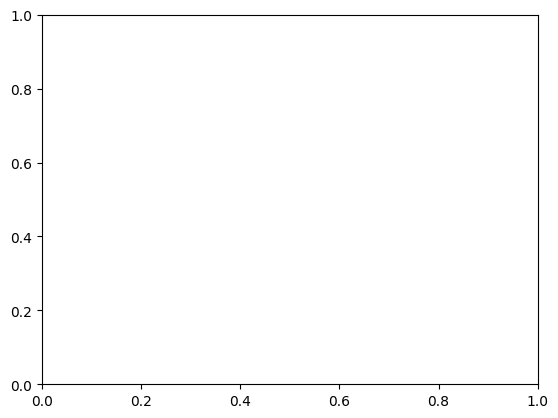

In [14]:
fig, ax = plt.subplots()

def CycleModel(model, callback, className, cycles = 100):
  mean, std = [], []

  for _ in range(cycles):
    print(f"Number {_} of {cycles}")
    model.learn(total_timesteps=2048, callback=callback)
    model.get_env().reset()
    m, s = evaluate_policy(model, model.get_env(), n_eval_episodes=25, deterministic=True)
    print(f"Deterministic mean: {m} and std: {s}")
    mean.append(m)
    std.append(s)

  mean = np.array(mean)
  std = np.array(std)
  ax.plot(range(cycles), mean, label=className)
  ax.fill_between(range(cycles), mean - std, mean+std, alpha=0.2)

In [15]:
class Torpedo_Counter():
    def __init__(self, seed = 42, low = 3, high = 8, max_fires = 10):
        self.low = low
        self.high = high
        self.rng = np.random.default_rng(seed)
        self.cooldown_time = 0
        self.generate_cooldown()
        self.fired = 0
        self.max_fires = max_fires
        self.fire = True

    def generate_cooldown(self):
        self.cooldown_time = self.rng.integers(low=self.low, high=self.high)

    def tick(self):
        if self.fire == True:
            self.cooldown_time -= 1

    def reset(self):
        self.fired = 0
        self.generate_cooldown()

    def can_fire(self):
        if self.fired >= self.max_fires:
            return False
        if self.cooldown_time <= 0:
            self.generate_cooldown()
            self.fired += 1
            return True
        else:
            self.tick()
            return False

In [16]:
def arrow_and_heatmap(model, env):
  map_explored = []
  
  final_boards = [
    [], [], [],
    [], [], [],
    [], [], [],
  ]
  final_directions = [
      [], [], [],
      [], [], [],
      [], [], [],
  ]
  grid_size = env.grid_size
  for x in range(grid_size):
    for y in range(grid_size):
      env.reset()
      if env.board[y, x] == 0:
        agent = np.array([y, x])
        obs, info = env.reset(manual_spawn=agent, random_damage=False)

        done = False
        while done == False:
          action, _ = model.predict(obs, deterministic=True)
          obs, reward, done, truncated, info = env.step(int(action))

      area_number = (y // 5) * 3 + (x // 5) + 1
      final_boards[area_number - 1].append(env.board)
      final_directions[area_number - 1].append(env.directions)

  for section in range(9):
      vectorized = np.array([[[env._vectorize_action[x] for x in row] for row in matrix] for matrix in final_directions[section]])
      vectorized_avg = np.mean(vectorized, axis=0).reshape(15*15, 2)
      y = vectorized_avg[..., 0:1] * -1
      x = vectorized_avg[..., 1:2]

      map_explored.append((((x == 0) & (y == 0)).sum() - 31) / (15*15 - 31))

  vectorized = np.array([[[[env._vectorize_action[x] for x in row] for row in matrix] for matrix in section] for section in final_directions])
  vectorized_avg = np.mean(vectorized, axis=1).reshape(9, 15*15, 2)
  y = vectorized_avg[..., 0:1] * -1
  x = vectorized_avg[..., 1:2]

  magnitude =  np.sqrt(x**2 + y**2)
  x_normalized = x / (magnitude + 1e-9)
  y_normalized = y / (magnitude + 1e-9)

  fig, ax = plt.subplots(3, 3, figsize=(9, 9))

  fig.suptitle(f"Map explored {np.mean(map_explored):.2f}")

  for section in range(9):
    x = section // 3
    y = section % 3

    # Replace numbers smaller than 2 with 0
    filtered_matrices = [np.where(matrix == 2, 0, matrix) for matrix in final_boards[section]]

    # Sum all filtered matrices
    result = np.sum(filtered_matrices, axis=0) / 3
    ax[x, y].imshow(result, cmap='viridis', interpolation='nearest', aspect="auto")

    X, Y = np.meshgrid(range(15), range(15))

    ax[x, y].quiver(
        X,
        Y,
        x_normalized[section],
        y_normalized[section],
        color="white",
        scale_units="width",
        scale=20
    )

    rect = patches.Rectangle((-0.5, -0.5), 15, 15, linewidth=1, edgecolor='white', facecolor='none')
    ax[x, y].add_patch(rect)
    rect = patches.Rectangle((y * 5 - 0.5, x* 5 - 0.5), 5, 5, linewidth=1, edgecolor='red', facecolor='none')
    ax[x, y].add_patch(rect)

    plt.subplots_adjust(wspace=0, hspace=0)
    for a in ax.flat:
      a.axis('off')

  plt.show()

  fig_overall, ax_overall = plt.subplots(1, 1, figsize=(9, 9))

  vectorized_overall_avg = np.mean(np.mean(vectorized, axis=1), axis=0).reshape(15*15, 2)
  y = vectorized_overall_avg[..., 0:1] * -1
  x = vectorized_overall_avg[..., 1:2]

  magnitude =  np.sqrt(x**2 + y**2)
  x_normalized = x / (magnitude + 1e-9)
  y_normalized = y / (magnitude + 1e-9)

  # Replace numbers smaller than 2 with 0
  filtered_matrices = [[np.where(matrix == 2, 0, matrix) for matrix in section] for section in final_boards]

  # Sum all filtered matrices
  result = np.sum(np.sum(filtered_matrices, axis=0), axis=0) / 3
  ax_overall.imshow(result, cmap='viridis', interpolation='nearest', aspect="auto")

  X, Y = np.meshgrid(range(15), range(15))

  ax_overall.quiver(
      X,
      Y,
      x_normalized,
      y_normalized,
      color="white",
  )

  ax_overall.axis('off')

  plt.show()



In [ ]:
class SimpleCaptainSonarEnv(Env):

  metadata = {"render_modes": ["human"], "render_fps": 30}

  def __init__(self, board, UNet, torpedo_counter : Torpedo_Counter, max_length = 50):
    super().__init__()
    self.agent               = np.array([0, 0], dtype=int)
    self.repairable_movement = np.array([0] * len(Action), dtype=int)
    self.permanent_movement  = np.array([0] * len(Action), dtype=int)
    self._board              = board.copy()
    self.board               = board.copy()
    self.grid_size           = board.shape[0]
    self.length              = 0
    self.max_length          = max_length
    self.resurfaced          = -1
    self.directions          = np.full(board.shape, Action.NOTHING.value)
    self.last_torpedo        = np.array([-1, -1], dtype=int)
    self.UNet                = UNet
    self.torpedo_counter     = torpedo_counter
    self.resurfaced_count    = 0
    self.actions_taken       = []

    """
    What can the RL agent see?
    > Agent coordinates: [x, y]
    — Range: [0, 14]

    > Repairable movement: [N, S, E, W]
    — Range: [0, 2]

    > Permanent damage movement: [N, S, E, W]
    — Range: [0, 2]
    """
    self.observation_space = Dict({
        # Agent coordinates: [x, y]
        "Coordinates": Box(low=0, high=self.grid_size - 1, shape=(2,), dtype=int),
        # Repairable movement: [N, S, E, W]
        "Repairable_movement": Box(low=0, high=len(Action)-1, shape=(len(Action),), dtype=int),
        # Permanent damage movement: [N, S, E, W]
        "Permanent_movement": Box(low=0, high=len(Action)-1, shape=(len(Action),), dtype=int),
        # Action masking: prevents illigal moves
        "action_mask": Box(low=0, high=1, shape=(len(Action),), dtype=int)
    })

    """
    What can agent do?
    > Move UP
    > Move DOWN
    > Move LEFT
    > Move RIGHT
    > Move Nothing
    > RESURFACE
    6 actions in total
    """
    self.action_space = Discrete(len(Action))

    # Each action vectorized
    self._vectorize_action = {
        # Going from row 1 to 0 is UP
        Action.UP.value:      np.array([ -1 ,  0 ]),
        # Going from row 0 to 1 is DOWN
        Action.DOWN.value:    np.array([  1 ,  0 ]),
        # Going from column 1 to 0 is LEFT
        Action.LEFT.value:    np.array([  0 , -1 ]),
        # Going from column 0 to 1 is RIGHT
        Action.RIGHT.value:   np.array([  0 ,  1 ]),
        Action.NOTHING.value: np.array([  0 ,  0 ]),
    }

  def update_UNet(self, UNet):
    self.UNet = UNet
    print("UNet updated")
  
  def get_UNet(self):
    return self.UNet

  def get_UNet_input(self):
    path = actions_to_paths([self.actions_taken])[0]
    path_mask = paths_to_masks([path])[0]
    path_mask = np.expand_dims(path_mask, axis=0)
    path_mask_standardized = standardize_masks(path_mask)[0]
    board = np.where(self._board == 2, 0, 1)
    return path_mask_standardized, board
  
  def get_UNet_output(self):
    path_mask_standardized, board = self.get_UNet_input()
    prediction = self.UNet(
        torch.tensor(path_mask_standardized).unsqueeze(0).unsqueeze(0).float(),
        torch.tensor(board).unsqueeze(0).unsqueeze(0).float()
    )
    prediction_numpy = prediction.cpu().detach().numpy().squeeze().reshape(15, 15)

    def softmax(x):
      x = np.exp(x)/sum(np.exp(x))  
      return x

    return softmax(prediction_numpy.flatten()).reshape(15, 15)

  def get_predicted_submarine_location(self):
    # Get the predicted submarine location from the UNet
    prediction_numpy = self.get_UNet_output()
    index = np.argmax(prediction_numpy)
    x = index % 15
    y = index // 15
    return np.array([y, x])
  
  def train_UNet(self, RL_model, epochs = 20):
    actions, paths = generate_data(self, RL_model, deterministic=False, trials=5, grid_size=self.grid_size)
    train, test, visualize = make_datasets_actions(paths, actions, board_UNet)
    UNet, loss_dict = train_model(
        train_data = train,
        test_data = test,
        visualize_data = visualize,
        model = self.UNet,
        loss_fn = nn.CrossEntropyLoss(),
        epochs=epochs,
        lr=1e-4,
        print_every=5,
        visualize_images=5,
        batch_size=32,
        visualize_every=epochs + 1
    )
    self.update_UNet(UNet)

    return loss_dict

  def step(self, action):
    done = False
    truncated = False

    """
    First, change the agent's action based on the algorithm's answer
    Give 1 reward as the longer the agent survives, the better
    """
    x_previous = self.agent[0]
    y_previous = self.agent[1]
    self.board[x_previous, y_previous] = Tile.TRAVELLED.value
    vectorized_movement = self._vectorize_action[action]
    self.agent += vectorized_movement
    reward = 1

    """
    Second, if agent is outside boundaries, in an island or already been there,
    which is not allowed, then reverse action and punish.
    Otherwise, note where agent has been on the board
    """
    true_action = action
    x = self.agent[0]
    y = self.agent[1]
    if x == -1 or y == -1 or x == self.grid_size or y == self.grid_size or self.board[x, y] == Tile.TRAVELLED.value or self.board[x, y] == Tile.ISLAND.value:
      self.agent -= vectorized_movement
      true_action = Action.NOTHING.value
    else:
      self.board[x, y] = Tile.SUBMARINE.value

    if true_action == Action.NOTHING.value:
      reward -= (self.repairable_movement[true_action] + 1)

    """
    Third, update repairable movement in the correct direction.
    If repairable movement is already 3,
    then add to permanent damage movement
    """
    if true_action == Action.NOTHING.value or self.repairable_movement[true_action] < 3:
      self.repairable_movement[true_action] += 1

    elif true_action != Action.NOTHING.value:
      self.permanent_movement[true_action] += 1

    """
    Fourth, add repair logic.
    Check if repairable_movement NORTH, SOUTH or WEST has 3 and EAST is at least 1,
    then substract for NORTH, SOUTH or WEST 3 and 1 from EAST
    """
    if true_action == Action.RIGHT.value and np.any(self.repairable_movement == 3):
      action_to_be_repaired = np.where(self.repairable_movement == 3)[0][0]

      # Only combination of (NORTH, SOUTH, WEST) x (EAST) is repairable
      if action_to_be_repaired != Action.RIGHT.value:
        self.repairable_movement[Action.RIGHT.value] -= 1
        self.repairable_movement[action_to_be_repaired] -= 3

    if true_action != Action.NOTHING.value and true_action != Action.RIGHT.value and self.repairable_movement[true_action] == 3 and self.repairable_movement[Action.RIGHT.value] > 0:
      self.repairable_movement[Action.RIGHT.value] -= 1
      self.repairable_movement[true_action] -= 3

    """
    Fifth, if repairable movement and permanent damage add up to 6 in any direction,
    then simulation is done and punish
    """
    if self.repairable_movement[true_action] + self.permanent_movement[true_action] >= 6:
      done = True

    """
    Sixth, if simulation has been running for X steps,
    then simulation is done and reward with X points
    """
    self.length += 1
    if self.length >= self.max_length:
      done = True
      truncated = True

    """
    Seventh, translate self.agent, self.repairable_movement
    and self.permanent_movement into oberservation_space
    """
    observation_space = self.get_observation_space()
    info = {}

    if true_action != Action.NOTHING.value:
      info["true_action"] = true_action
      info["agent_position"] = self.agent.copy()
      self.directions[x_previous, y_previous] = true_action
      self.actions_taken.append(true_action)
      self.travelled.append(self.agent.copy())
    
    if done == True:
      info["record"] = True
      info["directions"] = self.directions

    """
    Eight, torpedo cooldown -1, if on 0, then fire torpedo and reset cooldown
    """ 
    if self.torpedo_counter.can_fire():
      predicted_location = self.get_predicted_submarine_location()
      y, x = predicted_location
      self.last_torpedo[y, x] = self.torpedo_counter.fired

      info["torpedo_fired"] = predicted_location

      distance = np.abs(self.agent - predicted_location).max()
      if distance <= 1:
        # print(f"Torpedo hit at {predicted_location} at length {self.length}")
        done = True
        truncated = False
        reward = self.length - self.max_length
        info["torpedo_hit"] = True
      else:
        # print(f"Torpedo missed at {predicted_location} with distance {distance} at length {self.length}")
        pass

    return observation_space, int(reward), done, truncated, info

  def render(self, render_size = 7):
    '''
    Render boards:
    - Observation board: shows where the agent is, has been and islands
    - Input of UNet board: shows what the UNet sees
    - Output of UNet board: shows the prediction of UNet as a heatmap
    - Output of deterministic algorithm board: shows the prediction of deterministic algorithm as a heatmap
    '''

    fig, ax = plt.subplots(2, 2, figsize=(render_size, render_size))

    UNet_input, board = self.get_UNet_input()
    UNet_output = self.get_UNet_output()
    x_prediction, y_prediction = self.get_predicted_submarine_location()

    def sigmoid(x):
      return 1 / (1 + np.exp(-x))

    # Render Observation board
    observation_figure = ax[0, 0]
    render_board = self.board.copy()
    x, y = self.agent
    render_board[x, y] = Tile.SUBMARINE.value
    observation_figure.imshow(render_board)
    observation_figure.set_title(f"ObservationStep: {self.length}, Torpedo cooldown: {self.torpedo_counter.cooldown_time}")
    observation_figure.axis('off')
    circle = Circle((y_prediction, x_prediction), 0.2, fill=True, color="black", alpha=1)
    observation_figure.add_patch(circle)

    # Render Input of UNet
    UNet_input_figure = ax[0, 1]
    UNet_input_figure.imshow(UNet_input)
    UNet_input_figure.set_title(f"UNet input")
    UNet_input_figure.axis('off')

    # Render Output of UNet
    UNet_output_figure = ax[1, 0]
    UNet_output = np.where(UNet_output < 0.01, -6, UNet_output)
    UNet_output = sigmoid(UNet_output)
    UNet_output_figure.imshow(UNet_output, vmin=0, vmax=1)
    UNet_output_figure.set_title(f"UNet output")
    UNet_output_figure.axis('off')
    add_islands(UNet_output_figure)

    circle = Circle((y_prediction, x_prediction), 0.2, fill=True, color="black", alpha=1)
    UNet_output_figure.add_patch(circle)

    # Render Output of deterministic algorithm
    deterministic_figure = ax[1, 1]
    deterministic_output = deterministic_sub_finding(UNet_input, board)
    deterministic_output = np.where(deterministic_output == 0, -6, deterministic_output)
    deterministic_output = sigmoid(deterministic_output)
    deterministic_figure.imshow(deterministic_output, vmin=0, vmax=1)
    deterministic_figure.set_title(f"Deterministic output")
    deterministic_figure.axis('off')
    add_islands(deterministic_figure)

    circle = Circle((y_prediction, x_prediction), 0.2, fill=True, color="black", alpha=1)
    deterministic_figure.add_patch(circle)

    return observation_figure, UNet_input_figure, UNet_output_figure, deterministic_figure

  def reset(self, manual_spawn=False, random_damage=False, seed=None, options=None):
    super().reset(seed=seed)
    self.np_random = np.random.RandomState(seed)

    # Remove previous been points on board
    self.board = self._board.copy()
    self.directions = np.full(self.board.shape, Action.NOTHING.value)

    # Reset the length
    self.length = 0

    # Reset torpedo
    self.last_torpedo = np.zeros((self.grid_size, self.grid_size), dtype=int)
    self.torpedo_counter.reset()

    # Reset actions taken
    self.actions_taken = []

    # Initialize random starting position of submarine
    if type(manual_spawn) == bool:
      self.agent = self.np_random.randint(0, self.grid_size, 2)
      while self.board[self.agent[1], self.agent[0]] == Tile.ISLAND.value:
        self.agent = self.np_random.randint(0, self.grid_size, 2)
    else:
      self.agent = manual_spawn
    x = self.agent[0]
    y = self.agent[1]
    self.board[x, y] = Tile.SUBMARINE.value
    self.travelled = [self.agent.copy()]

    # Reset movement trackers
    if random_damage:
      self.repairable_movement = self.np_random.randint(0, 3 + 1, 4)
      self.permanent_movement  = self.np_random.randint(0, 3 + 1, 4)
    else:
      self.repairable_movement = np.array([0] * len(Action))
      self.permanent_movement  = np.array([0] * len(Action))

    # Return observation
    return (self.get_observation_space(), {})

  def get_observation_space(self):
    action_mask = []
    current_position = self.agent.copy()
    for a in Action:
      if a == Action.DOWN or a == Action.RIGHT or a == Action.UP or a == Action.LEFT:
        vectorized_movement = self._vectorize_action[a.value]
        future_position = current_position + vectorized_movement
        x = future_position[0]
        y = future_position[1]
        if x == -1 or y == -1 or x >= self.grid_size or y >= self.grid_size or self.board[x, y] == Tile.TRAVELLED.value or self.board[x, y] == Tile.ISLAND.value:
          # 0 is Invalid
          action_mask.append(0)
        else:
          # 1 is Valid
          action_mask.append(1)
      else:
        # Resurface and Nothing are always valid
        action_mask.append(1)

    return {
        # Agent coordinates: [x, y]
        "Coordinates": self.agent,
        # Repairable movement: [N, S, E, W]
        "Repairable_movement": self.repairable_movement,
        # Permanent damage movement: [N, S, E, W]
        "Permanent_movement": self.permanent_movement,
        # Action mask
        "action_mask": np.array(action_mask)
    }


## Agent 2

In [42]:
class IntermediateCaptainSonarEnv(SimpleCaptainSonarEnv):
  def __init__(self, board, UNet, torpedo_counter, max_length = 50):
    super().__init__(board, UNet, torpedo_counter, max_length)
    self.observation_space["Coordinates"] = Box(low=0, high=1, shape=(self.grid_size ** 2 * len(Tile),), dtype=int)
    self.encoder = OneHotEncoder(sparse_output=False, categories=[range(len(Tile))])

  def get_observation_space(self):
    observation_space = super().get_observation_space()
    encoded_board = self.board.reshape(-1, 1)
    encoded_board = self.encoder.fit_transform(encoded_board).flatten()
    encoded_board = encoded_board.astype(np.int64)
    observation_space["Coordinates"] = encoded_board
    return observation_space

In [19]:
# Initialize torpedo counter
torp_counter = Torpedo_Counter(seed=42, low=25, high=50, max_fires=10)
# Initialize agent 2 environment
intermediate_env = IntermediateCaptainSonarEnv(
    board = board_numpy, 
    UNet = model_2_4_current, 
    torpedo_counter = torp_counter, 
    max_length = max_length
)
# Check environment with in-built function
check_env(intermediate_env)
# Initialize PPO model and load in weights from Agent 2 training
intermediate_model = PPO("MultiInputPolicy", intermediate_env, verbose=1, learning_rate=1e-4)
intermediate_model.policy.load_state_dict(torch.load("intermediate_weights.pth"))

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


<All keys matched successfully>

## Agent 4

In [20]:
class CustomHybrid(BaseFeaturesExtractor):
    def __init__(self, observation_space: gymnasium.spaces.Dict, linear_dim = 32, feature_extract = 32):
        # We do not know features-dim here before going over all the items,
        # so put something dummy for now. PyTorch requires calling
        # nn.Module.__init__ before adding modules
        super().__init__(observation_space, features_dim=1)

        extractors = {}

        total_concat_size = 0
        # We need to know size of the output of this extractor,
        # so go over all the spaces and compute output feature sizes
        for key, subspace in observation_space.spaces.items():
            if "movement" in key or key == "action_mask":
                # These are discrete
                features = subspace.shape[0]
                extractors[key] = nn.Sequential(
                    nn.Linear(features, linear_dim),
                    nn.ReLU(),
                    nn.Linear(linear_dim, linear_dim),
                    nn.ReLU(),
                    nn.Linear(linear_dim, linear_dim),
                    nn.ReLU(),
                )
                total_concat_size += linear_dim
            elif key == "Coordinates":
                # Run through CNN
                n_input_channels = subspace.shape[0]
                extractors[key] = nn.Sequential(
                  nn.Conv2d(n_input_channels, feature_extract, kernel_size=3, stride=1, padding=1),
                  nn.ReLU(),
                  nn.Conv2d(feature_extract, feature_extract, kernel_size=3, stride=1, padding=1),
                  nn.ReLU(),
                  nn.Conv2d(feature_extract, feature_extract, kernel_size=3, stride=1, padding=1),
                  nn.ReLU(),
                  nn.MaxPool2d(2, 2),
                  nn.Conv2d(feature_extract, feature_extract, kernel_size=3, stride=1, padding=1),
                  nn.ReLU(),
                  nn.Conv2d(feature_extract, feature_extract, kernel_size=3, stride=1, padding=1),
                  nn.ReLU(),
                  nn.Conv2d(feature_extract, feature_extract, kernel_size=3, stride=1, padding=1),
                  nn.ReLU(),
                  nn.MaxPool2d(2, 2),
                  nn.Flatten(),
                )
                total_concat_size += subspace.shape[1] // 2 // 2 * feature_extract + subspace.shape[1] // 2 // 2 * feature_extract

        self.extractors = nn.ModuleDict(extractors)

        # Update the features dim manually
        self._features_dim = 384

    def forward(self, observations) -> torch.Tensor:
        encoded_tensor_list = []

        # self.extractors contain nn.Modules that do all the processing.
        for key, extractor in self.extractors.items():
            encoded_tensor_list.append(extractor(observations[key]))
        # Return a (B, self._features_dim) PyTorch tensor, where B is batch dimension.
        return torch.cat(encoded_tensor_list, dim=1)

policy_kwargs_hybrid = dict(
    features_extractor_class=CustomHybrid,
    features_extractor_kwargs=dict(linear_dim=32, feature_extract=32),
)

In [21]:
class HybridCaptainSonarEnv(SimpleCaptainSonarEnv):
  def __init__(self, board, UNet, torpedo_counter, max_length = 50):
    super().__init__(board, UNet, torpedo_counter, max_length)

    self.board = self.board.astype(np.uint8)
    self.observation_space["Coordinates"] = Box(low=0, high=len(Tile), shape=(len(Tile), self.grid_size, self.grid_size), dtype=np.uint8)
    self.encoder = OneHotEncoder(sparse_output=False, categories=[range(len(Tile))])

  def get_observation_space(self):
    observation_space = super().get_observation_space()
    encoded_board = self.board.reshape(-1, 1)
    encoded_board = self.encoder.fit_transform(encoded_board).T
    encoded_board = encoded_board.astype(np.uint8)
    observation_space["Coordinates"] = encoded_board.reshape(len(Tile), self.grid_size, self.grid_size)
    return observation_space

In [22]:
# Initialize torpedo counter
torp_counter = Torpedo_Counter(seed=42, low=5, high=10, max_fires=10)
# Initialize agent 4 environment
hybrid_env = HybridCaptainSonarEnv(
    board = board_numpy, 
    UNet = model_2_4_current, 
    torpedo_counter = torp_counter, 
    max_length = max_length
)
# Check environment with in-built function
check_env(hybrid_env)
# Initialize PPO model and load in weights from Agent 4 training
loaded_hybrid_model = PPO("MultiInputPolicy", hybrid_env, verbose=1, policy_kwargs=policy_kwargs_hybrid, learning_rate=1e-4)
loaded_hybrid_model.policy.load_state_dict(torch.load("hybrid_weights.pth"))

c:\Users\20213032\OneDrive - TU Eindhoven\Documents\TUe\Y5\Q3\BEP\.venv\Lib\site-packages\stable_baselines3\common\env_checker.py:75: UserWarning: It seems that your observation space Coordinates is an image but the upper and lower bounds are not in [0, 255]. Because the CNN policy normalize automatically the observation you may encounter issue if the values are not in that range.
  warnings.warn(
c:\Users\20213032\OneDrive - TU Eindhoven\Documents\TUe\Y5\Q3\BEP\.venv\Lib\site-packages\stable_baselines3\common\env_checker.py:88: UserWarning: The minimal resolution for an image is 36x36 for the default `CnnPolicy`. You might need to use a custom features extractor cf. https://stable-baselines3.readthedocs.io/en/master/guide/custom_policy.html
  warnings.warn(


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


<All keys matched successfully>

# Environment test

In [19]:
hybrid_env.reset(manual_spawn=np.array([4, 10]))
observation = hybrid_env.get_observation_space()
print()

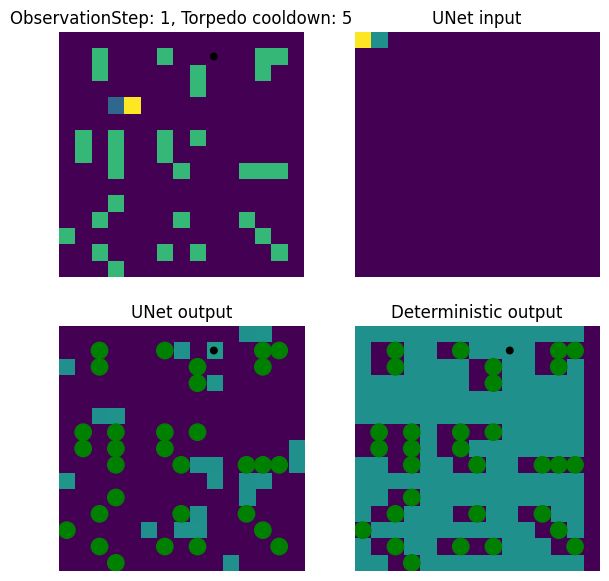

In [26]:
# action = loaded_hybrid_model.predict(observation, deterministic=True)[0]
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3
NOTHING = 4
action = 2
observation, reward, done, truncated, info = hybrid_env.step(int(action))

if "torpedo_fired" in info:
    observation_space, _, _, _ =  hybrid_env.render()
    position = info["torpedo_fired"]

    for x in range(-1, 2):
        for y in range(-1, 2):
            explosion = Circle((position[1] + y, position[0] + x), 0.2, fill=True, color="orange", alpha=0.5)
            observation_space.add_patch(explosion)
else:
    hybrid_env.render()
plt.show()

if observation["action_mask"].sum() == 1 or observation["Repairable_movement"][-1] > 10 or done == True:
    if info.get("torpedo_hit") == True:
        hybrid_env.reset()
        print("Torpedo hit at reset!")
    else:   
        hybrid_env.reset(hybrid_env.agent)
        print("RESURFACED")
    observation = hybrid_env.get_observation_space()

# Shoot on confidence instead of cooldown

(np.float64(-0.5), np.float64(14.5), np.float64(14.5), np.float64(-0.5))

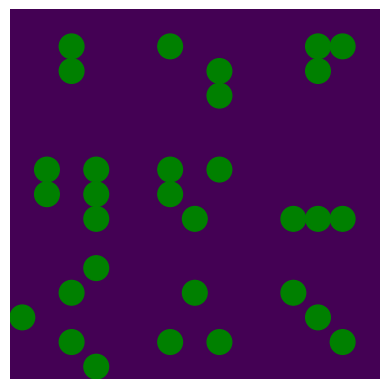

In [61]:
zeroes = np.zeros((15, 15))
fig, ax = plt.subplots()
add_islands(ax)
ax.imshow(zeroes, vmin=0, vmax=1)
ax.axis('off')

# Training Agent 2

- First train the agent and store weights every 100 cycles
- Second train the UNet and store the weights
- Repeat

In [ ]:
callback_intermediate = ActionLoggerCallback()
for i in range(10):
    CycleModel(intermediate_model, callback_intermediate, "Intermediate", 20)

    intermediate_env.train_UNet(intermediate_model, epochs=3)

    # Store UNet training weights after each cycle
    file_name = f"back_and_forth\\UNet_weights_{i*100}.pth"
    torch.save(intermediate_env.UNet.state_dict(), file_name)

    # Store the training weights of the intermediate model after each cycle
    file_name = f"back_and_forth\\intermediate_weights_{i*100}.pth"
    torch.save(intermediate_model.policy.state_dict(), file_name)

    # Initialize PPO model and load in the new UNet
    intermediate_model = PPO("MultiInputPolicy", intermediate_env, verbose=1, learning_rate=1e-4)
    intermediate_model.policy.load_state_dict(torch.load(file_name))

Number 0 of 20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 36.4     |
|    ep_rew_mean     | 10.3     |
| time/              |          |
|    fps             | 252      |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 2048     |
---------------------------------
Deterministic mean: 15.16 and std: 23.675607700753957
Number 1 of 20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 33.5     |
|    ep_rew_mean     | 9.02     |
| time/              |          |
|    fps             | 232      |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 2048     |
---------------------------------
Deterministic mean: 22.68 and std: 21.579101000736802
Number 2 of 20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 33.2     |
|    ep_rew_mean     | 11.2     |
| time/              |         

100%|██████████| 15/15 [00:15<00:00,  1.06s/it]


Processed 1 of 1
len(sequences)=5672, len(subdivided_paths)=5672
Masks created
Masks standardized
Final positions calculated
Train test split done
Paths split done
Datasets created
Allocated memory: 33020416
Epoch    Train RMSRE      Test RMSRE


100%|██████████| 142/142 [00:02<00:00, 70.61it/s]


UNet updated
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Number 0 of 20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 30       |
|    ep_rew_mean     | 7.16     |
| time/              |          |
|    fps             | 213      |
|    iterations      | 1        |
|    time_elapsed    | 9        |
|    total_timesteps | 2048     |
---------------------------------
Deterministic mean: 4.96 and std: 31.529643194936412
Number 1 of 20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 30       |
|    ep_rew_mean     | 9.01     |
| time/              |          |
|    fps             | 241      |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 2048     |
---------------------------------
Deterministic mean: 12.84 and std: 25.294552773275118
Number 2 of 20
---------------------------------
| rollout/           |    

...

UNet updated
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Number 0 of 20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 28.4     |
|    ep_rew_mean     | 16.9     |
| time/              |          |
|    fps             | 215      |
|    iterations      | 1        |
|    time_elapsed    | 9        |
|    total_timesteps | 2048     |
---------------------------------
Deterministic mean: 13.84 and std: 23.74814519073016
Number 1 of 20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 27.4     |
|    ep_rew_mean     | 16.2     |
| time/              |          |
|    fps             | 195      |
|    iterations      | 1        |
|    time_elapsed    | 10       |
|    total_timesteps | 2048     |
---------------------------------
Deterministic mean: 16.96 and std: 20.213817056657064
Number 2 of 20
---------------------------------
| rollout/           |    

100%|██████████| 15/15 [00:13<00:00,  1.10it/s]


Processed 1 of 1
len(sequences)=4226, len(subdivided_paths)=4226
Masks created
Masks standardized
Final positions calculated
Train test split done
Paths split done
Datasets created
Allocated memory: 33964032
Epoch    Train RMSRE      Test RMSRE


100%|██████████| 106/106 [00:02<00:00, 48.63it/s]


UNet updated
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


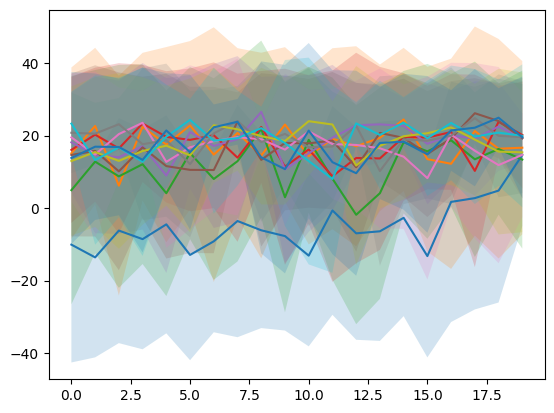

In [34]:
fig

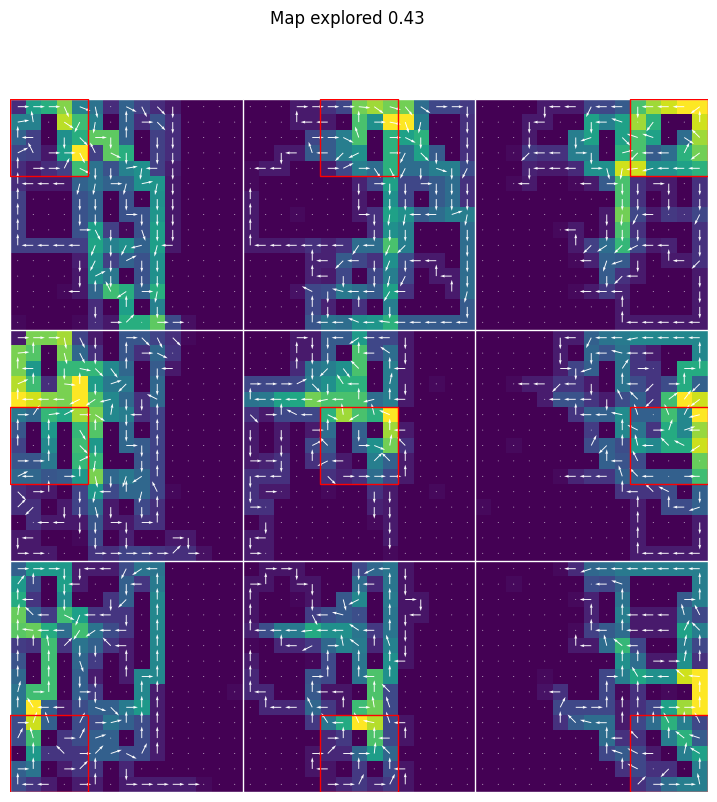

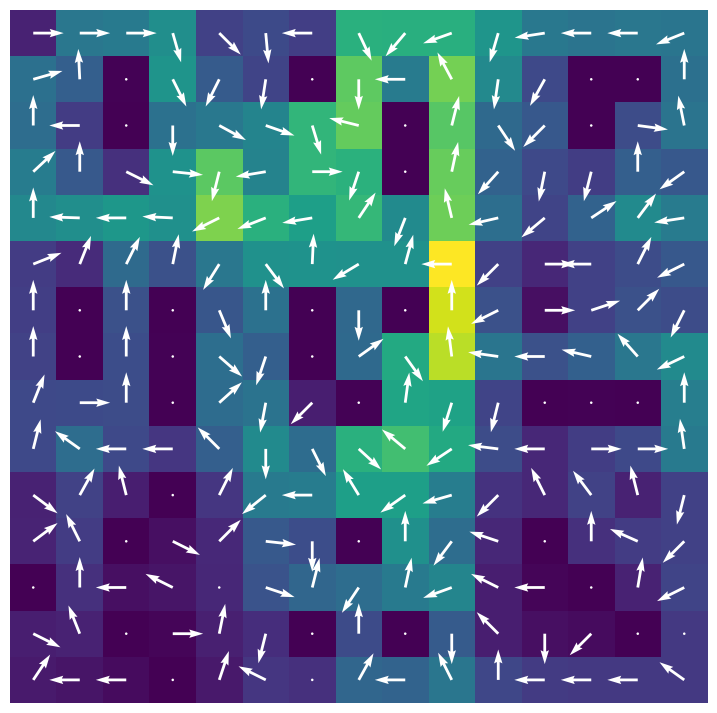

In [35]:
arrow_and_heatmap(intermediate_model, intermediate_env)

100%|██████████| 3208/3208 [00:24<00:00, 133.29it/s]


Method Deterministic has mean + std < 1 at path length 32 with value=np.float64(0.9400000000000001)
Method Deterministic has mean + std < 1 at path length 34 with value=np.float64(0.9)
Method Deterministic has mean + std < 1 at path length 35 with value=np.float64(0.9400000000000001)
Method Deterministic has mean + std < 1 at path length 36 with value=np.float64(0.63)
Method Deterministic has mean + std < 1 at path length 37 with value=np.float64(0.87)
Method Deterministic has mean + std < 1 at path length 38 with value=np.float64(0.09)
Method Deterministic has mean + std < 1 at path length 39 with value=np.float64(0.22)
Method Deterministic has mean + std < 1 at path length 40 with value=np.float64(0.0)
Method Deterministic has mean + std < 1 at path length 41 with value=np.float64(0.0)
Method Deterministic has mean + std < 1 at path length 42 with value=np.float64(0.0)
Method Deterministic has mean + std < 1 at path length 43 with value=np.float64(0.0)
Method Deterministic has mean +

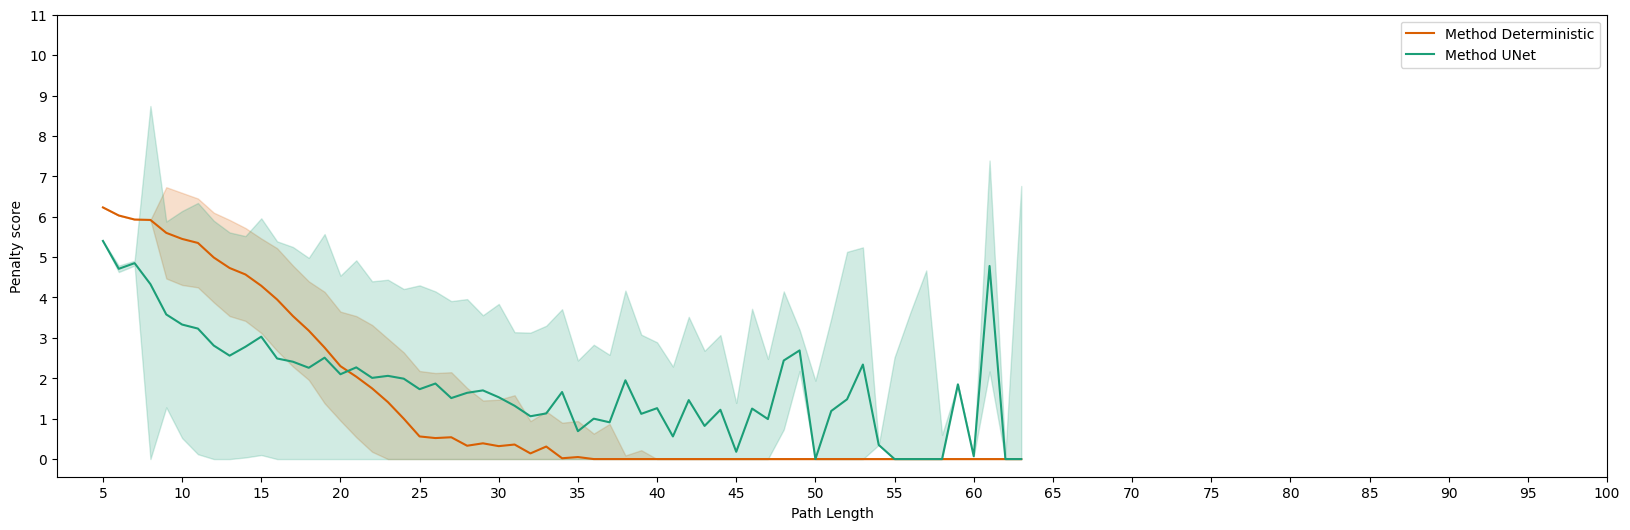

In [59]:
# actions, paths = generate_data(intermediate_env, intermediate_model, deterministic=False, trials=4)
# train, test, visualize = make_datasets_actions(paths, actions, board_UNet)
# test_data_loader = DataLoader(visualize, batch_size=1, shuffle=True, generator=torch.Generator(device=device))
compare_UNet_to_Deterministic(test_data_loader, intermediate_env.UNet)

In [ ]:
actions, paths = generate_data(intermediate_env, intermediate_model, deterministic=True, trials=10)
train, test, visualize = make_datasets_actions(paths, actions, board_UNet)
test_data_loader = DataLoader(visualize, batch_size=1, shuffle=True, generator=torch.Generator(device=device))
compare_UNet_to_Deterministic(test_data_loader, model_2_current)